In [1]:
!unzip archive.zip


Archive:  archive.zip
  inflating: arabica_coffee_certification_information.csv  
  inflating: arabica_coffee_cupping_scores.csv  
  inflating: arabica_coffee_full_table.csv  
  inflating: arabica_coffee_green_analysis.csv  
  inflating: arabica_coffee_sample_infomation.csv  


In [3]:
import pandas as pd

df = pd.read_csv("arabica_coffee_full_table.csv")

In [4]:
df.head()

,coffee_id,Country_of_Origin,Farm_Name,Lot_Number,Mill,ICO_Number,Company,Altitude,Region,Producer,...,Color,Category_One_Defects,Category_Two_Defects,Quakers,Expiration,Certification_Body,Certification_Address,Certification_Contact,parsed_expiration,parsed_grading_date
0,#647123,Guatemala,san francisco cotzal,11/441/50,"inmobiliaria e inversiones dos mil, s.a.",11/441/50,"inmobiliaria e inversiones dos mil, s.a.",1600.0,quiche,san francisco cotzal,...,Green,0,1,3.0,June 22 2023,Asociacion Nacional Del Café,"5a Calle 0-50, Zona 14 Guatemala City, Guatema...",Brayan Cifuentes -,2023-06-22,2022-06-22
1,#927000,Guatemala,San jose del lago,11/15/95,San jose del lago,11/15/95,"Peter Schoenfeld, S.A.",1600.0,Atitlán,"Cafetalera Paquim, S.A.",...,Green,0,2,1.0,April 16 2024,Asociacion Nacional Del Café,"5a Calle 0-50, Zona 14 Guatemala City, Guatema...",Brayan Cifuentes -,2024-04-16,2023-04-17
2,#902618,Guatemala,varias fincas,11/15/51,El Trèbol/Lìnea Gourmet,11/15/51,"Peter Schoenfeld, S.A.",1550.0,Oriente Santa rosa,varios productores,...,Green,0,2,1.0,March 21 2024,Asociacion Nacional Del Café,"5a Calle 0-50, Zona 14 Guatemala City, Guatema...",Brayan Cifuentes -,2024-03-21,2023-03-22
3,#781706,Guatemala,San jose del lago,11/15/96,San jose del lago,11/15/96,"Peter Schoenfeld, S.A.",1600.0,Atitlán,"Cafetalera Paquim, S.A.",...,Green,0,1,0.0,April 16 2024,Asociacion Nacional Del Café,"5a Calle 0-50, Zona 14 Guatemala City, Guatema...",Brayan Cifuentes -,2024-04-16,2023-04-17
4,#237025,Guatemala,Finca Alta Luz,11-63-657,NaN,11-63-657,"Retrillas del pacifico, s.a.",1350.0,Huehuetenango,Maria de los Angeles Perez,...,Green,0,5,1.0,April 25 2024,Asociacion Nacional Del Café,"5a Calle 0-50, Zona 14 Guatemala City, Guatema...",Brayan Cifuentes -,2024-04-25,2023-04-26


In [5]:
df.shape

(1509, 42)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1509 entries, 0 to 1508
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   coffee_id              1509 non-null   object 
 1   Country_of_Origin      1508 non-null   object 
 2   Farm_Name              1151 non-null   object 
 3   Lot_Number             467 non-null    object 
 4   Mill                   1196 non-null   object 
 5   ICO_Number             1230 non-null   object 
 6   Company                1300 non-null   object 
 7   Altitude               1279 non-null   float64
 8   Region                 1450 non-null   object 
 9   Producer               1278 non-null   object 
 10  Number_of_Bags         1509 non-null   int64  
 11  Bag_Weight             1509 non-null   object 
 12  In_Country_Partner     1509 non-null   object 
 13  Harvest_Year           1462 non-null   object 
 14  Grading_Date           1509 non-null   object 
 15  Owne

In [7]:
df.isnull().sum()

,0
coffee_id,0
Country_of_Origin,1
Farm_Name,358
Lot_Number,1042
Mill,313
ICO_Number,279
Company,209
Altitude,230
Region,59
Producer,231


In [8]:
porcentaje_nulos = (df.isnull().sum() / len(df) * 100).round(2)

porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False)

,0
Defects,86.88
Status,86.88
Lot_Number,69.05
Farm_Name,23.72
Mill,20.74
ICO_Number,18.49
Color,17.69
Producer,15.31
Altitude,15.24
Company,13.85


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["coffee_id"].duplicated().sum()

np.int64(0)

In [11]:
df["Processing_Method"].value_counts(dropna=False)

,count
Processing_Method,
Washed / Wet,931
Natural / Dry,293
NaN,157
Semi-washed / Semi-pulped,56
Pulped natural / honey,40
Other,26
Semi Washed,1
Double Carbonic Maceration / Natural,1
Wet Hulling,1


In [12]:
df["Altitude"].describe()

,Altitude
count,1279.000000
mean,1299.964261
std,423.674817
min,0.000000
25%,1100.000000
50%,1311.000000
75%,1600.000000
max,2560.000000


In [13]:
df[df["Altitude"] == 0][
    ["coffee_id", "Country_of_Origin", "Region", "Farm_Name", "Altitude"]
]

,coffee_id,Country_of_Origin,Region,Farm_Name,Altitude
1172,987,Ethiopia,sidamo,NaN,0.0


In [14]:
df["Total_Cup_Points"].describe()

,Total_Cup_Points
count,1509.000000
mean,82.333612
std,3.378540
min,0.000000
25%,81.420000
50%,82.670000
75%,83.830000
max,90.580000


In [15]:
df[df["Total_Cup_Points"] == 0][
    ["coffee_id", "Country_of_Origin", "Aroma", "Flavor",
     "Acidity", "Body", "Overall", "Total_Cup_Points"]
]

,coffee_id,Country_of_Origin,Aroma,Flavor,Acidity,Body,Overall,Total_Cup_Points
1031,1312,Honduras,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
columnas_sensoriales = [
    "Aroma", "Flavor", "Aftertaste", "Acidity", "Body",
    "Balance", "Uniformity", "Clean_Cup", "Sweetness",
    "Overall", "Total_Cup_Points"
]

(df[columnas_sensoriales] == 0).sum()

,0
Aroma,1
Flavor,1
Aftertaste,1
Acidity,1
Body,1
Balance,1
Uniformity,1
Clean_Cup,2
Sweetness,1
Overall,1


In [17]:
df[df["Clean_Cup"] == 0][
    ["coffee_id", "Country_of_Origin", "Aroma", "Flavor",
     "Acidity", "Body", "Clean_Cup", "Sweetness",
     "Overall", "Total_Cup_Points"]
]

,coffee_id,Country_of_Origin,Aroma,Flavor,Acidity,Body,Clean_Cup,Sweetness,Overall,Total_Cup_Points
441,1307,Mexico,7.08,6.83,7.42,7.25,0.0,10.0,6.75,68.33
1031,1312,Honduras,0.00,0.00,0.00,0.00,0.0,0.0,0.00,0.00


In [18]:
df_limpio = df.copy()

In [20]:
df_limpio = df_limpio[df_limpio["coffee_id"] != "1312"].copy()

In [22]:
df_limpio.shape

(1508, 42)

In [23]:
import numpy as np

df_limpio.loc[df_limpio["Altitude"] == 0, "Altitude"] = np.nan

In [24]:
df_limpio["Altitude"].describe()

,Altitude
count,1277.000000
mean,1300.903908
std,422.431763
min,1.000000
25%,1100.000000
50%,1311.000000
75%,1600.000000
max,2560.000000


In [25]:
df_limpio[df_limpio["Altitude"] < 100][
    ["coffee_id", "Country_of_Origin", "Region", "Farm_Name", "Altitude"]
].sort_values("Altitude")

,coffee_id,Country_of_Origin,Region,Farm_Name,Altitude
1072,482,Brazil,south of minas,rio verde,1.00
1074,964,Brazil,south of minas,rio verde,1.00
1070,280,Brazil,south of minas,rio verde,1.00
1094,762,Brazil,south of minas,rio verde,1.00
1092,614,Brazil,south of minas,rio verde,1.00
1091,878,Brazil,south of minas,rio verde,1.00
1085,738,Brazil,south of minas,rio verde,1.00
1084,839,Brazil,south of minas,rio verde,1.00
1098,781,Brazil,south of minas,rio verde,1.00
1097,840,Brazil,south of minas,rio verde,1.00


In [26]:
df_limpio.loc[df_limpio["Altitude"] < 100, "Altitude"] = np.nan

In [27]:
df_limpio["Altitude"].describe()

,Altitude
count,1259.000000
mean,1319.435377
std,395.748941
min,100.000000
25%,1100.000000
50%,1311.000000
75%,1600.000000
max,2560.000000


In [28]:
columnas_analisis = [
    "coffee_id",
    "Country_of_Origin",
    "Altitude",
    "Harvest_Year",
    "Variety",
    "Processing_Method",
    "Aroma",
    "Flavor",
    "Aftertaste",
    "Acidity",
    "Body",
    "Balance",
    "Uniformity",
    "Clean_Cup",
    "Sweetness",
    "Overall",
    "Total_Cup_Points",
    "Moisture",
    "Color",
    "Category_One_Defects",
    "Category_Two_Defects",
    "Quakers"
]

cafe = df_limpio[columnas_analisis].copy()

cafe.shape

(1508, 22)

In [29]:
nulos_cafe = pd.DataFrame({
    "Cantidad_nulos": cafe.isnull().sum(),
    "Porcentaje_nulos": (cafe.isnull().sum() / len(cafe) * 100).round(2)
})

nulos_cafe[nulos_cafe["Cantidad_nulos"] > 0]

,Cantidad_nulos,Porcentaje_nulos
Country_of_Origin,1,0.07
Altitude,249,16.51
Harvest_Year,47,3.12
Variety,208,13.79
Processing_Method,156,10.34
Color,267,17.71
Quakers,1,0.07


In [30]:
columnas_categoricas = [
    "Country_of_Origin",
    "Harvest_Year",
    "Variety",
    "Processing_Method",
    "Color"
]

cafe[columnas_categoricas] = cafe[columnas_categoricas].fillna("No informado")

In [31]:
cafe.isnull().sum()

,0
coffee_id,0
Country_of_Origin,0
Altitude,249
Harvest_Year,0
Variety,0
Processing_Method,0
Aroma,0
Flavor,0
Aftertaste,0
Acidity,0


In [32]:
cafe.to_csv("coffee_quality_limpio.csv", index=False)

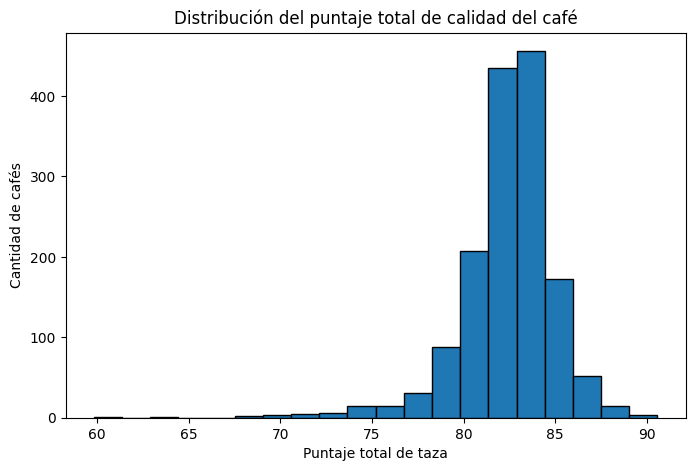

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(cafe["Total_Cup_Points"], bins=20, edgecolor="black")

plt.title("Distribución del puntaje total de calidad del café")
plt.xlabel("Puntaje total de taza")
plt.ylabel("Cantidad de cafés")

plt.show()

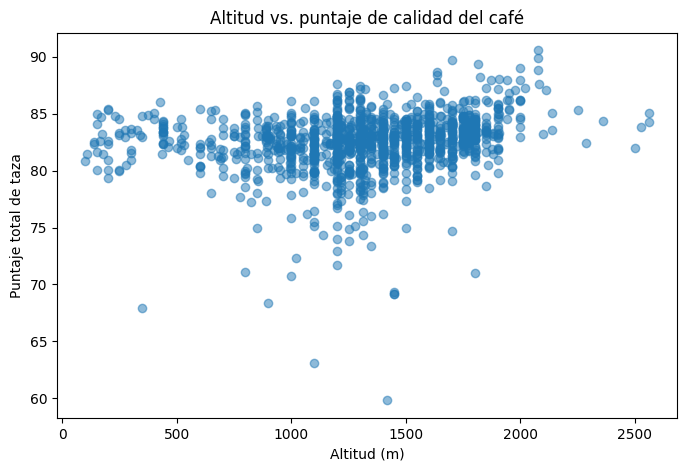

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(
    cafe["Altitude"],
    cafe["Total_Cup_Points"],
    alpha=0.5
)

plt.title("Altitud vs. puntaje de calidad del café")
plt.xlabel("Altitud (m)")
plt.ylabel("Puntaje total de taza")

plt.show()

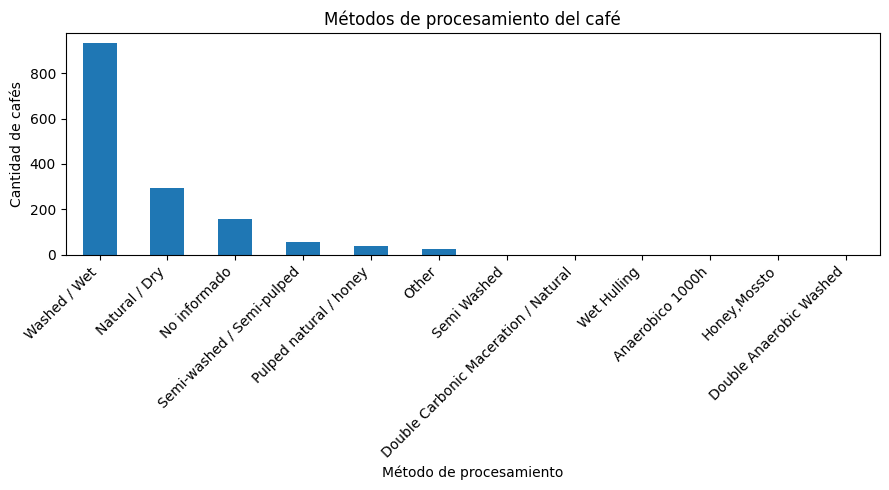

In [35]:
conteo_procesamiento = cafe["Processing_Method"].value_counts()

plt.figure(figsize=(9, 5))

conteo_procesamiento.plot(kind="bar")

plt.title("Métodos de procesamiento del café")
plt.xlabel("Método de procesamiento")
plt.ylabel("Cantidad de cafés")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [36]:
resumen_limpieza = pd.DataFrame({
    "Aspecto": [
        "Número de registros",
        "Número de variables",
        "Registros duplicados",
        "Variables seleccionadas para análisis",
        "Evaluaciones sensoriales inválidas",
        "Valores faltantes restantes"
    ],
    "Dataset original": [
        len(df),
        df.shape[1],
        df.duplicated().sum(),
        df.shape[1],
        1,
        df.isnull().sum().sum()
    ],
    "Dataset preparado": [
        len(cafe),
        cafe.shape[1],
        cafe.duplicated().sum(),
        cafe.shape[1],
        0,
        cafe.isnull().sum().sum()
    ]
})

resumen_limpieza

,Aspecto,Dataset original,Dataset preparado
0,Número de registros,1509,1508
1,Número de variables,42,22
2,Registros duplicados,0,0
3,Variables seleccionadas para análisis,42,22
4,Evaluaciones sensoriales inválidas,1,0
5,Valores faltantes restantes,6031,250


In [ ]:
#Módulo 2

In [37]:
media = cafe["Total_Cup_Points"].mean()
mediana = cafe["Total_Cup_Points"].median()
moda = cafe["Total_Cup_Points"].mode()[0]

print("Media:", round(media, 2))
print("Mediana:", round(mediana, 2))
print("Moda:", round(moda, 2))

Media: 82.39
Mediana: 82.67
Moda: 83.17


In [38]:
rango = cafe["Total_Cup_Points"].max() - cafe["Total_Cup_Points"].min()
varianza = cafe["Total_Cup_Points"].var()
desviacion = cafe["Total_Cup_Points"].std()

print("Rango:", round(rango, 2))
print("Varianza:", round(varianza, 2))
print("Desviación estándar:", round(desviacion, 2))

Rango: 30.75
Varianza: 6.92
Desviación estándar: 2.63


In [39]:
variables_comparacion = [
    "Total_Cup_Points",
    "Altitude",
    "Moisture",
    "Category_One_Defects",
    "Category_Two_Defects"
]

correlaciones = cafe[variables_comparacion].corr()

correlaciones["Total_Cup_Points"].sort_values(ascending=False)

,Total_Cup_Points
Total_Cup_Points,1.000000
Altitude,0.199674
Moisture,-0.112154
Category_One_Defects,-0.150477
Category_Two_Defects,-0.298877


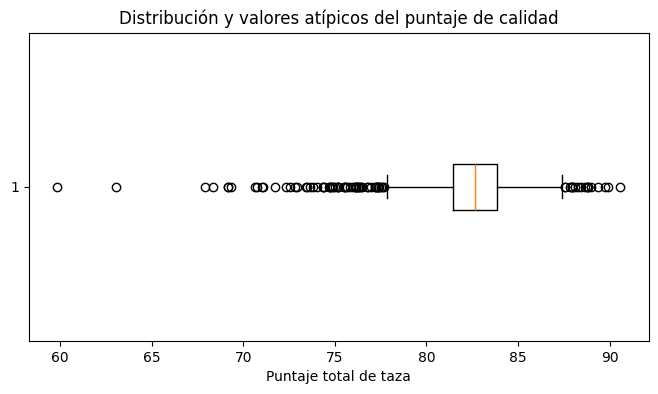

In [40]:
plt.figure(figsize=(8, 4))

plt.boxplot(cafe["Total_Cup_Points"], vert=False)

plt.title("Distribución y valores atípicos del puntaje de calidad")
plt.xlabel("Puntaje total de taza")

plt.show()

In [41]:
resumen_estadistico = pd.DataFrame({
    "Medida": [
        "Media",
        "Mediana",
        "Moda",
        "Rango",
        "Varianza",
        "Desviación estándar"
    ],
    "Total_Cup_Points": [
        media,
        mediana,
        moda,
        rango,
        varianza,
        desviacion
    ]
})

resumen_estadistico["Total_Cup_Points"] = resumen_estadistico["Total_Cup_Points"].round(2)

resumen_estadistico

,Medida,Total_Cup_Points
0,Media,82.39
1,Mediana,82.67
2,Moda,83.17
3,Rango,30.75
4,Varianza,6.92
5,Desviación estándar,2.63


In [ ]:
#Modulo 3

In [42]:
variables_modelo = [
    "Altitude",
    "Moisture",
    "Category_One_Defects",
    "Category_Two_Defects",
    "Total_Cup_Points"
]

datos_modelo = cafe[variables_modelo].dropna()

print("Datos disponibles para el modelo:", datos_modelo.shape)
datos_modelo.head()

Datos disponibles para el modelo: (1259, 5)


,Altitude,Moisture,Category_One_Defects,Category_Two_Defects,Total_Cup_Points
0,1600.0,0.117,0,1,84.92
1,1600.0,0.100,0,2,83.92
2,1550.0,0.110,0,2,84.08
3,1600.0,0.100,0,1,84.25
4,1350.0,0.092,0,5,84.33


In [43]:
from sklearn.model_selection import train_test_split

X = datos_modelo[
    [
        "Altitude",
        "Moisture",
        "Category_One_Defects",
        "Category_Two_Defects"
    ]
]

y = datos_modelo["Total_Cup_Points"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (1007, 4)
Datos de prueba: (252, 4)


In [44]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [45]:
y_pred = modelo.predict(X_test)

comparacion = pd.DataFrame({
    "Puntaje real": y_test.values,
    "Puntaje predicho": y_pred
})

comparacion.head(10).round(2)

,Puntaje real,Puntaje predicho
0,76.17,78.77
1,84.58,83.29
2,84.67,83.35
3,83.42,83.35
4,83.25,82.09
5,79.08,82.25
6,82.92,82.07
7,86.25,83.59
8,82.75,82.37
9,88.25,83.03


In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 3))

MAE: 1.71
RMSE: 2.56
R²: 0.116


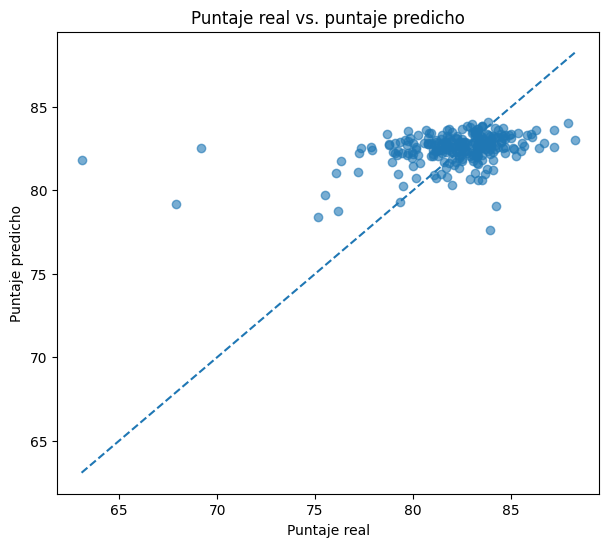

In [47]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Puntaje real vs. puntaje predicho")
plt.xlabel("Puntaje real")
plt.ylabel("Puntaje predicho")

plt.show()